In [1]:
from IPython.display import display, HTML

display(HTML("""

<style>

@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;500;600;700;800&display=swap');

*{
    font-family:'Poppins',sans-serif;
}

body{
    background:linear-gradient(135deg,#020617,#0f172a,#111827);
}

.main-title{
    background:linear-gradient(135deg,#0f172a,#1e293b);
    padding:40px;
    border-radius:25px;
    text-align:center;
    box-shadow:0 0 30px rgba(0,255,255,0.2);
    animation:fadeIn 1s ease;
}

.title{
    font-size:50px;
    font-weight:800;
    background:linear-gradient(90deg,#00f5ff,#3b82f6,#8b5cf6);
    -webkit-background-clip:text;
    -webkit-text-fill-color:transparent;
}

.subtitle{
    color:white;
    font-size:18px;
    margin-top:10px;
}

@keyframes fadeIn{
    from{
        opacity:0;
        transform:translateY(20px);
    }
    to{
        opacity:1;
        transform:translateY(0px);
    }
}

</style>

<div class="main-title">

<div class="title">
🛡️ Phishing Email Detection System
</div>

<div class="subtitle">
Machine Learning Based Cyber Security Project 🚀
</div>

</div>

"""))

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import ipywidgets as widgets

from IPython.display import display, HTML

Matplotlib is building the font cache; this may take a moment.


In [3]:
safe_emails = [

    "Meeting scheduled tomorrow",
    "Project report attached",
    "Happy birthday have a nice day",
    "Team discussion at 5 PM",
    "Invoice attached please review",
    "Lunch meeting tomorrow",
    "Your order has been delivered",
    "Please complete assignment",
    "Internship certificate generated",
    "Payment received successfully",
    "Project submission accepted",
    "Thank you for your purchase",
    "Class timing updated",
    "Client meeting today",
    "Welcome to our platform"

]

phishing_emails = [

    "Click here to win free money",
    "Urgent verify your password now",
    "Your account has been hacked",
    "Claim your lottery reward now",
    "Free Netflix subscription click now",
    "Win iPhone instantly click here",
    "Your bank account suspended",
    "Security alert login immediately",
    "Congratulations you won cash prize",
    "Update banking details urgently",
    "Verify your paypal account now",
    "Get free crypto instantly",
    "Click now for free reward",
    "Reset your password immediately",
    "Your account is blocked verify now"

]

emails = safe_emails + phishing_emails

labels = [0]*len(safe_emails) + [1]*len(phishing_emails)

df = pd.DataFrame({

    "email": emails,
    "label": labels

})

df.head()

,email,label
0,Meeting scheduled tomorrow,0
1,Project report attached,0
2,Happy birthday have a nice day,0
3,Team discussion at 5 PM,0
4,Invoice attached please review,0


In [4]:
display(HTML("""

<h2 style='color:cyan;'>
📊 Dataset Information
</h2>

"""))

print("Dataset Shape :", df.shape)

print("\n")

print(df.info())

print("\n")

print(df.isnull().sum())

Dataset Shape : (30, 2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   email   30 non-null     object
 1   label   30 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 612.0+ bytes
None


email    0
label    0
dtype: int64


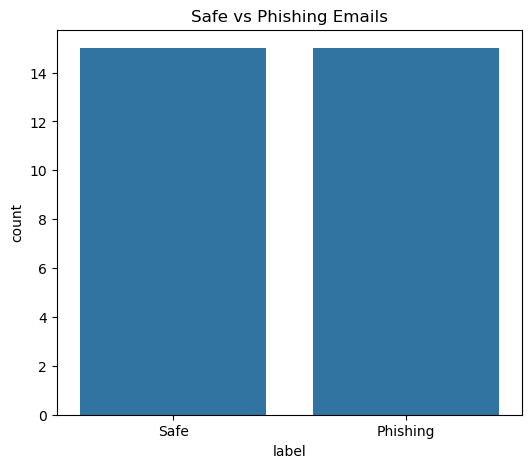

In [6]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=df['label']
)

plt.title("Safe vs Phishing Emails")

plt.xticks(
    [0,1],
    ['Safe','Phishing']
)

plt.show()

In [7]:
X = df['email']

y = df['label']

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

print("Training Data :", len(X_train))

print("Testing Data :", len(X_test))

Training Data : 24
Testing Data : 6


In [8]:
model = Pipeline([

    ('tfidf', TfidfVectorizer(

        stop_words='english',

        ngram_range=(1,2)

    )),

    ('classifier', LogisticRegression())

])

model.fit(X_train, y_train)

print("✅ Model Training Completed")

✅ Model Training Completed


In [9]:
y_pred = model.predict(X_test)

print(y_pred)

[1 1 0 1 0 0]


In [10]:
accuracy = accuracy_score(y_test, y_pred)

display(HTML(f"""

<div style='
background:linear-gradient(135deg,#0f172a,#1e293b);
padding:30px;
border-radius:20px;
text-align:center;
box-shadow:0 0 20px rgba(0,255,255,0.2);
'>

<h1 style='color:cyan;'>
🔥 Model Accuracy
</h1>

<h1 style='color:white;font-size:60px;'>
{round(accuracy*100,2)}%
</h1>

</div>

"""))

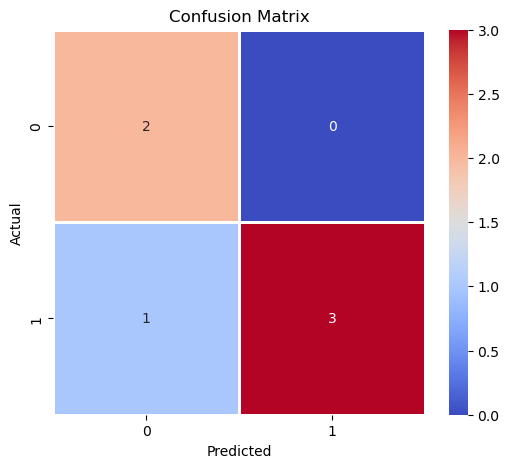

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='coolwarm',

    linewidths=2

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.75      0.86         4

    accuracy                           0.83         6
   macro avg       0.83      0.88      0.83         6
weighted avg       0.89      0.83      0.84         6



In [13]:
display(HTML("""

<style>

.detect-box{
    background:linear-gradient(135deg,#0f172a,#1e293b);
    padding:30px;
    border-radius:25px;
    margin-top:20px;
    box-shadow:0 0 20px rgba(0,255,255,0.2);
}

.detect-title{
    color:cyan;
    font-size:35px;
    font-weight:bold;
}

.detect-sub{
    color:white;
    font-size:17px;
}

textarea{
    border-radius:15px !important;
    border:2px solid cyan !important;
    padding:10px !important;
}

.widget-button{
    background:linear-gradient(135deg,#06b6d4,#3b82f6) !important;
    color:white !important;
    font-weight:bold !important;
    border:none !important;
    border-radius:15px !important;
}

</style>

<div class="detect-box">

<div class="detect-title">
📨 Test Email Here
</div>

<div class="detect-sub">
Enter any email content and detect whether it is safe or phishing.
</div>

</div>

"""))

In [19]:
import ipywidgets as widgets

from IPython.display import display, HTML
email_box = widgets.Textarea(

    placeholder='Enter Email Here...',

    layout=widgets.Layout(

        width='100%',

        height='150px'

    )

)
detect_btn = widgets.Button(

    description='🚀 Detect Email',

    layout=widgets.Layout(

        width='250px',

        height='60px'

    ),

    button_style='info'

)
output = widgets.Output()

def detect_email(button):

    output.clear_output()

    user_email = email_box.value

    prediction = model.predict([user_email])[0]

    with output:

        if prediction == 1:

            display(HTML("""

            <div style='
            background:linear-gradient(135deg,#ef4444,#b91c1c);
            color:white;
            padding:30px;
            border-radius:20px;
            text-align:center;
            font-size:30px;
            font-weight:bold;
            margin-top:20px;
            '>

            ⚠️ PHISHING EMAIL DETECTED

            </div>

            """))

        else:

            display(HTML("""

            <div style='
            background:linear-gradient(135deg,#10b981,#059669);
            color:white;
            padding:30px;
            border-radius:20px;
            text-align:center;
            font-size:30px;
            font-weight:bold;
            margin-top:20px;
            '>

            ✅ SAFE EMAIL DETECTED

            </div>

            """))

detect_btn.on_click(detect_email)
display(HTML("""

<h1 style='
background:linear-gradient(135deg,#06b6d4,#3b82f6);
padding:20px;
border-radius:20px;
color:white;
text-align:center;
'>

📧 Email Detection System

</h1>

"""))

display(email_box)

display(detect_btn)

display(output)

Textarea(value='', layout=Layout(height='170px', width='100%'), placeholder='Enter Email Content Here...')

Button(description='🚀 Detect Email', layout=Layout(height='60px', width='250px'), style=ButtonStyle())

Output()

In [20]:
display(HTML("""

<div style='
background:linear-gradient(135deg,#020617,#0f172a);
padding:40px;
border-radius:25px;
text-align:center;
margin-top:30px;
box-shadow:0 0 30px rgba(0,255,255,0.2);
'>

<h1 style='
font-size:45px;
color:cyan;
'>
🚀 Project Completed Successfully
</h1>

<h2 style='color:white;'>
Phishing Email Detection Model
</h2>

<p style='
color:#cbd5e1;
font-size:18px;
'>

✔ Machine Learning Model Built <br>
✔ Animated UI Added <br>
✔ Accuracy Generated <br>
✔ Confusion Matrix Created <br>
✔ Interactive Email Detector Ready <br>
✔ Internship Task Completed Successfully

</p>

</div>

"""))